In [1]:
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

# Wyłączanie anty-aliasowania (zniekształca wykresy)
mpl.rcParams['image.interpolation'] = 'nearest'

Wczytanie obrazka, przygotowanie prostej aproksymacji RGB, 
2D kostki danych (X), wykres RGB i przykładowych wektorów hiperspektralnych.

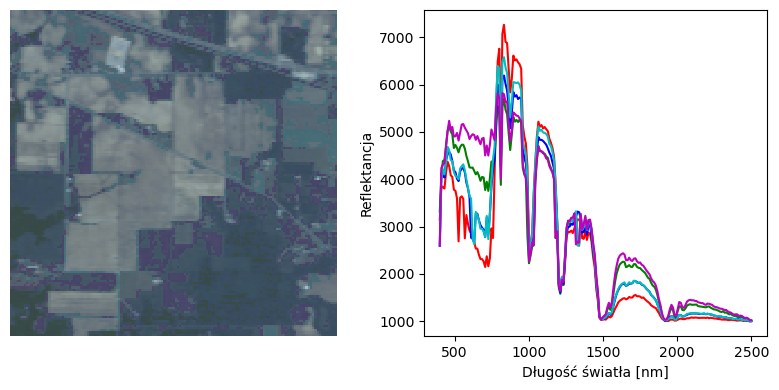

In [2]:
data = np.load('indian_pines.npy')
rgb = np.array(data[:, :, np.array([29, 20, 11])], float) / np.max(data)
X = np.reshape(data, (-1, data.shape[-1]))
bands = np.linspace(400, 2500, data.shape[-1])

plt.figure(figsize=(8, 4))
plt.subplot(121)
plt.imshow(rgb)
plt.axis('off')
plt.subplot(122)
for i, c in zip(np.random.choice(len(X), size=5, replace=False), 'rgbcmyk'):    
    plt.plot(bands, X[i], c=c)
plt.ylabel('Reflektancja')
plt.xlabel('Długość światła [nm]')
plt.tight_layout()
plt.show()

Wybrane przykłady algorytmów

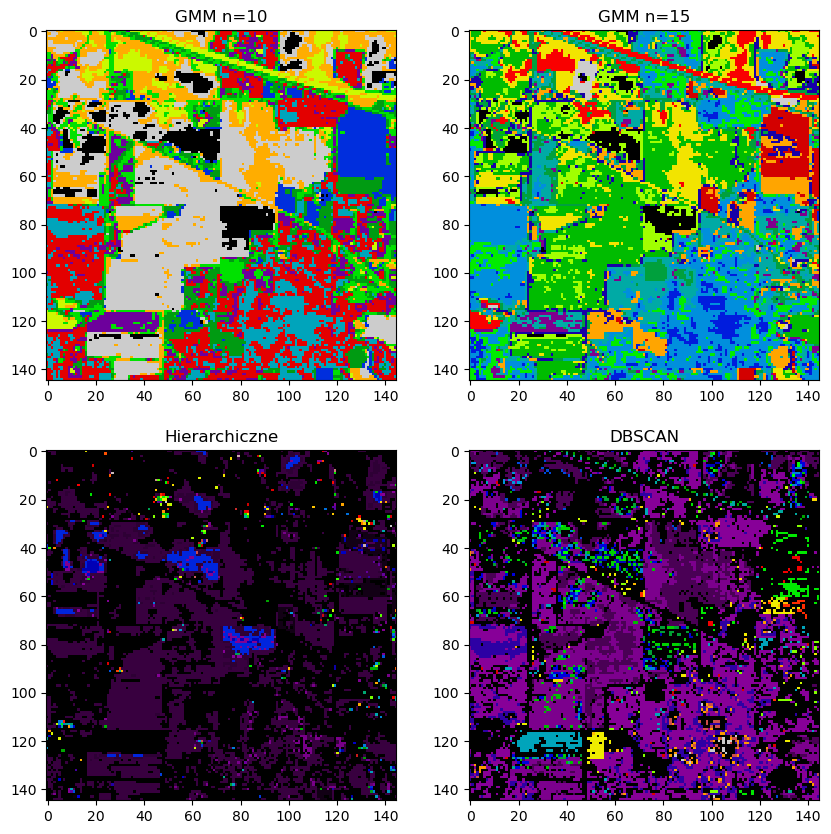

In [3]:
X = StandardScaler().fit_transform(X)
plt.figure(figsize=(10, 10))
plt.subplot(221)
model = GaussianMixture(n_components=10, covariance_type="full", random_state=0)
labels = model.fit_predict(X[:, ::2])
plt.imshow(labels.reshape(data.shape[:2]), cmap=plt.cm.nipy_spectral)
plt.title('GMM n=10')
plt.subplot(222)
model = GaussianMixture(n_components=15, covariance_type="full", random_state=0)
labels = model.fit_predict(X[:, ::2])
plt.imshow(labels.reshape(data.shape[:2]), cmap=plt.cm.nipy_spectral)
plt.title('GMM n=15')
plt.subplot(223)
model = AgglomerativeClustering(n_clusters=350, linkage="single")
labels = model.fit_predict(X[:, ::4])
plt.imshow(labels.reshape(data.shape[:2]), cmap=plt.cm.nipy_spectral)
plt.title('Hierarchiczne')
plt.subplot(224)
model = DBSCAN(eps=2, min_samples=20)
labels = model.fit_predict(X[:, ::2])
plt.imshow(labels.reshape(data.shape[:2]), cmap=plt.cm.nipy_spectral)
plt.title('DBSCAN')
plt.show()

Wzorcowy obraz klas

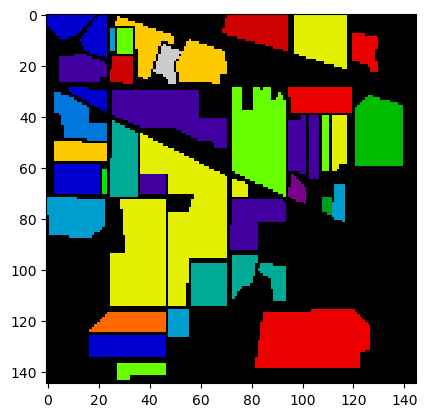

In [5]:
ground_truth = np.load('gt.npy')
plt.imshow(ground_truth, cmap=plt.cm.nipy_spectral)
plt.show()